# 分词

分词是将句子拆分成一个个独立的词或token的过程

Transformer模型处理的是向量，而用户输入的是文本句子，因此需要先对句子进行分词，再生成向量。分词将输入文本拆分为模型可处理的最小单元，确保每个单元具有相对完整和独立的语义，并为每个单元分配一个唯一标识符——token

## 分词的流程

分词流程包括规范化、预分词、模型处理和后处理

-规范化对文本进行清洗，去除无用字符，统一大小写和数字，确保编码一致，并进行词形还原或词干提取
- 预分词会基于简单规则来初步分割文本
- 模型处理阶段将预分词结果送入分词模型或依据词表进行分词，根据算法(如BPE)生成词表，并据此拆分文本为token
- 后处理阶段包括序列填充和截断、添加特殊token和构建注意力掩码等操作，以确保编码后的文本满足模型输入要求

## 分词器

分词器主要负责分词和扩展词表

理想的分词器应具备高压缩率、高覆盖率、训练友好、语言无关和无损压缩等特性

## 分词的粒度

### 按单词粒度分

传统的词表构建方法首先对句子进行分词，然后统计词频并选取频数最高的前n个词组成词表，每个词分配一个唯一的ID

**优势**

能够较好的保持语义的完整性，易于切分句子，尤其适合英文这类具有明显单词边界的语言

**劣势**

- 词表规模可能过大，导致计算效率极低，内存消耗增加
- 存在OOV（Out-of-Vocabulary，词汇表外词）、低频词训练不足、难以有效处理予以关系等问题

### 按字符粒度分

此分词方法将单词拆分为单个字符及特殊符号

**优势**

字符数量相对较少，基本能够涵盖所有文本序列，不存在OOV问题

**劣势**

- 丢失了单词边界信息，导致语义表达能力较弱，增加了建模难度
- 由于序列长度显著增加，计算成本上升，训练过程难以收敛
- 对于中文而言，单字往往难以完整表达语义

### 按子词粒度分

子词是当前LLM的主流切词粒度，对应的三种主流算法分别是：BPE(Byte Pair Encoding)、WordPiece和Unigram Language Model

## Llama3分词器源码

### 整体设计：两个类 + 一个 Rust 引擎

Llama2 的分词器基于 SentencePiece（词表仅 3.2 万），Llama3 则整个换成了 OpenAI 开源的 **tiktoken** 库（GPT-4 同款 BPE 实现）：

| 对比项 | Llama2（SentencePiece） | Llama3（tiktoken） |
| --- | --- | --- |
| 词表大小 | 32,000 | 128,256 |
| 压缩率 | 中文/代码切得很碎，token 数多 | 词表更大，同样文本切出的 token 更少 |
| 实现速度 | C++ 实现 | Rust 实现，快约一个数量级 |

官方源码 `llama/tokenizer.py` 只有 **两个类**，职责非常清晰：

![](../src/token1.png)

- **Tokenizer**：核心分词器，加载词表，完成 `文本 ↔ token 编号` 的编码与解码
- **ChatFormat**：对话格式化器，把"多轮对话"拼成模型要求的 prompt 格式（编码时调用 Tokenizer）

下面按数据流顺序逐步拆解：**加载词表 → Tokenizer 类 → 预切分演示 → ChatFormat 类 → 实战测试**。
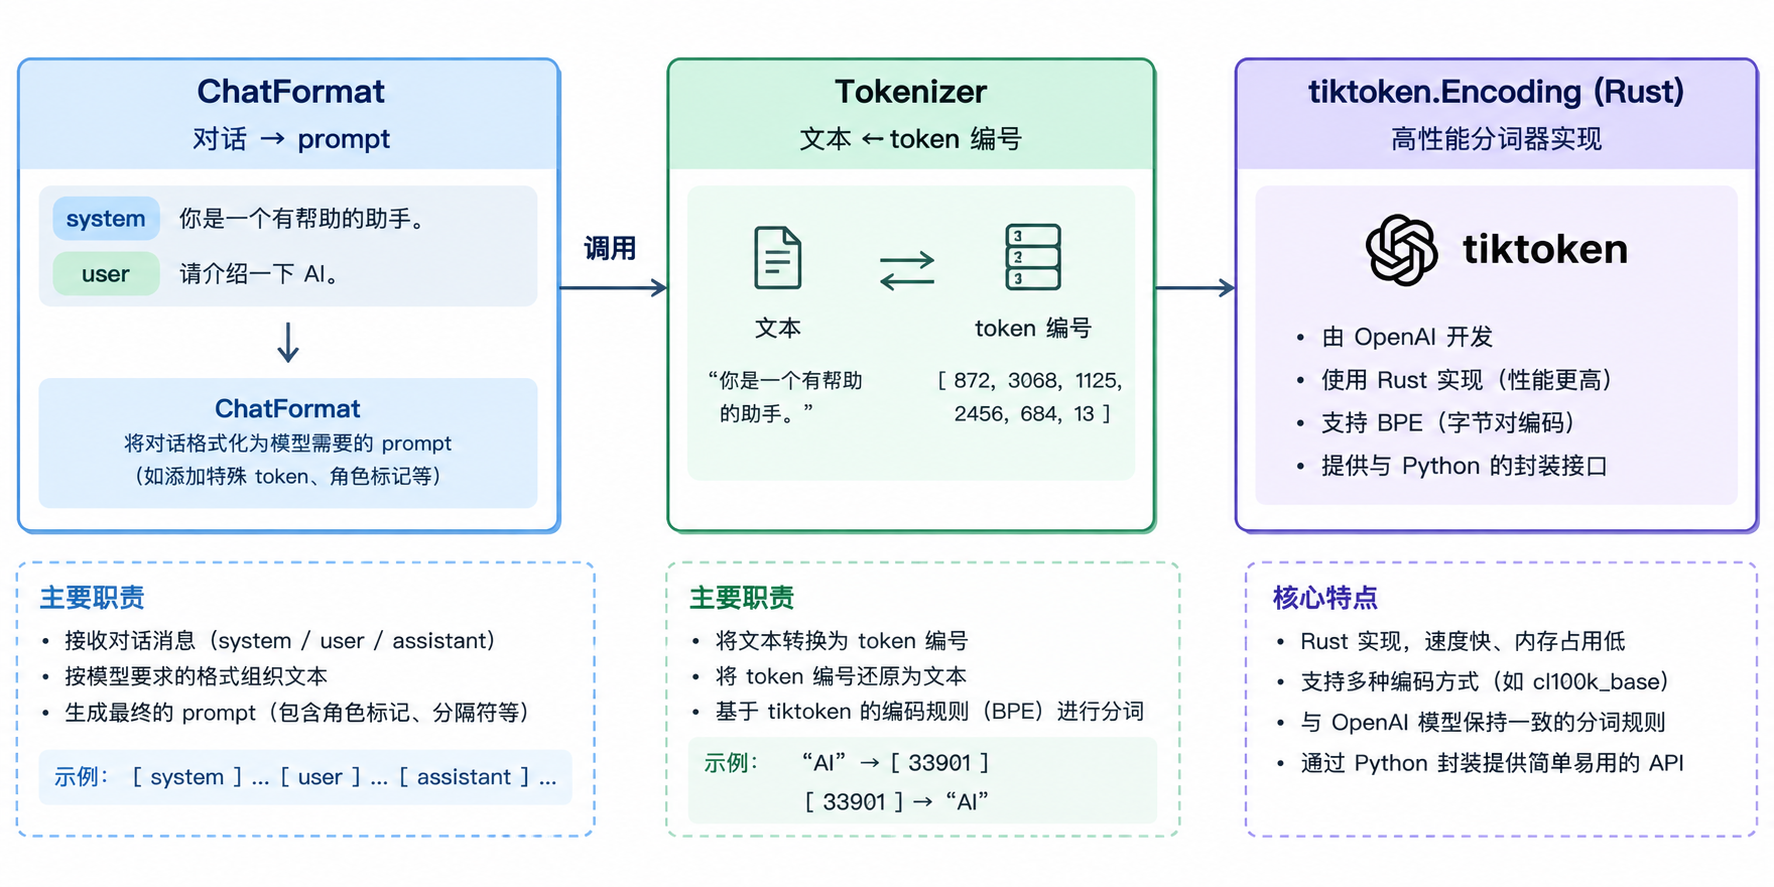

In [1]:
import base64
import os
import regex
from pathlib import Path
from typing import (
    AbstractSet,
    cast,
    Collection,
    Dict,
    Iterator,
    List,
    Literal,
    Sequence,
    TypedDict,
    Union,
)

import tiktoken                      # OpenAI 开源的高性能 BPE 分词库（Rust 实现）
from tiktoken.load import load_tiktoken_bpe  # 官方提供的词表读取函数

# 词表文件路径（与本 notebook 同目录）
TOKENIZER_PATH = "./tokenizer.model"

### 第 1 步：加载词表

Llama3 的 `tokenizer.model` 虽然保留着 `.model` 后缀，但**内部已经不是 SentencePiece 的二进制格式了**，而是 tiktoken 的纯文本格式 —— 每行一条记录：

```
base64编码的词元  编号
IQ== 0            →  b'!'  的编号是 0
Ig== 1            →  b'"'  的编号是 1
...
```

整个词表共 **128,000** 条记录，本质是一个 `bytes → int` 的字典。tiktoken 官方提供了 `load_tiktoken_bpe()` 来读取，其实逻辑非常简单，我们自己几行代码就能实现：

In [2]:
def my_load_tiktoken_bpe(model_path: str) -> Dict[bytes, int]:
    """读取 tiktoken 词表文件，返回 {词元(bytes): 编号(int)} 映射。

    tiktoken 词表就是纯文本文件，每行格式为「base64编码的词元 编号」，例如::

        IQ== 0        →  b'!' 的编号是 0
        SGVsbG8= 153839  →  b'Hello' 的编号是 153839

    （Llama3 虽然保留了 .model 后缀，但内部已经不是 SentencePiece 了）
    """
    mergeable_ranks: Dict[bytes, int] = {}
    with open(model_path, "rb") as f:
        for line in f:                       # 逐行读取
            line = line.strip()
            if not line:                     # 跳过空行
                continue
            token_b64, rank = line.split()   # 拆成 [base64词元, 编号] 两列
            token = base64.b64decode(token_b64)  # base64 解码，还原词元的真实字节
            mergeable_ranks[token] = int(rank)
    return mergeable_ranks

# 用我们自己写的解析器加载词表，效果与官方 load_tiktoken_bpe 完全一致
mergeable_ranks = my_load_tiktoken_bpe(TOKENIZER_PATH)
print(f"词表加载完成：共 {len(mergeable_ranks):,} 个普通词元")
print("前 5 项示例：", [(t, r) for t, r in list(mergeable_ranks.items())[:5]])

词表加载完成：共 128,000 个普通词元
前 5 项示例： [(b'!', 0), (b'"', 1), (b'#', 2), (b'$', 3), (b'%', 4)]


### 第 2 步：Tokenizer 类

核心类，`__init__` 里做了 4 件事，重点理解**词表的 id 空间布局**：

![](../src/token2.png)

另一个重点是 `pat_str` —— **BPE 预切分正则**。BPE 并不是对整句话直接合并，而是先用正则把文本"粗切"成小片段（英文缩写、单词、1~3 位数字、标点串、换行等），再对每个片段分别做 BPE 合并。这是 GPT-4 / Llama3 通用的切分方案。

最后拼装 `tiktoken.Encoding(...)`：它由 Rust 实现，真正的编码/解码工作都由它完成。

In [3]:
Role = Literal["system", "user", "assistant"]

class Message(TypedDict):
    """一条对话消息：角色 + 内容"""
    role: Role
    content: str

Dialog = Sequence[Message]  # 一段对话 = 若干条消息


class Tokenizer:
    """Llama3 分词器：负责「文本 <-> token 编号」的相互转换。

    整个类只做三件事：
      1. __init__  : 加载词表、登记特殊 token、创建 tiktoken 编码器
      2. encode    : 文本 → token 编号列表
      3. decode    : token 编号列表 → 文本
    """

    # ---------- 类常量 ----------
    num_reserved_special_tokens = 256   # 词表尾部预留 256 个特殊 token 槽位

    # BPE 预切分正则：先把文本"粗切"成小片段，再对每个片段做 BPE 合并。
    # 规则大致是：英文缩写('s/'t/...)、单词、1~3位数字、标点符号串、换行、其余空白
    pat_str = r"(?i:'s|'t|'re|'ve|'m|'ll|'d)|[^\r\n\p{L}\p{N}]?\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]+[\r\n]*|\s*[\r\n]+|\s+(?!\S)|\s+"

    def __init__(self, model_path: str):
        """加载词表并初始化 tiktoken 编码器。"""4
        assert os.path.isfile(model_path), model_path

        # ① 加载普通词表：{b'!': 0, b'Hello': 153839, ...}，共 128,000 项
        mergeable_ranks = load_tiktoken_bpe(model_path)
        num_base_tokens = len(mergeable_ranks)

        # ② 登记特殊 token：占用 id 128000 ~ 128255，共 256 个
        #    前 10 个有固定用途，其余 246 个是纯预留（微调时可以自定义）
        special_tokens = [
            "<|begin_of_text|>",              # 128000  文本开头
            "<|end_of_text|>",                # 128001  文本结尾
            "<|reserved_special_token_0|>",   # 128002  预留
            "<|reserved_special_token_1|>",   # 128003  预留
            "<|reserved_special_token_2|>",   # 128004  预留
            "<|reserved_special_token_3|>",   # 128005  预留
            "<|start_header_id|>",            # 128006  消息头开始
            "<|end_header_id|>",              # 128007  消息头结束
            "<|reserved_special_token_4|>",   # 128008  预留
            "<|eot_id|>",                     # 128009  一轮消息结束 (end of turn)
        ] + [
            # 128010 ~ 128255：246 个纯预留槽位
            f"<|reserved_special_token_{i}|>"
            for i in range(5, self.num_reserved_special_tokens - 5)
        ]
        # 建立 {名字: id} 映射：id = 128000 + 在列表中的下标
        self.special_tokens = {
            token: num_base_tokens + i for i, token in enumerate(special_tokens)
        }

        # ③ 创建 tiktoken 编码器（Rust 实现，真正的编解码都由它完成）
        self.model = tiktoken.Encoding(
            name=Path(model_path).name,
            pat_str=self.pat_str,               # 预切分正则
            mergeable_ranks=mergeable_ranks,    # 普通词表
            special_tokens=self.special_tokens, # 特殊词表
        )

        # ④ 记录常用属性
        self.n_words: int = self.model.n_vocab  # 词表总数 = 128000 + 256 = 128256
        self.bos_id: int = self.special_tokens["<|begin_of_text|>"]
        self.eos_id: int = self.special_tokens["<|end_of_text|>"]
        self.pad_id: int = -1                   # Llama3 约定 padding 用 -1（不占词表 id）
        self.stop_tokens = {                    # 生成停止符：出现任一个即视为对话结束
            self.special_tokens["<|end_of_text|>"],
            self.special_tokens["<|eot_id|>"],
        }

    # ==================== 文本 → token 编号 ====================
    def encode(
        self,
        s: str,
        *,
        bos: bool,
        eos: bool,
        allowed_special: Union[Literal["all"], AbstractSet[str]] = set(),
        disallowed_special: Union[Literal["all"], Collection[str]] = (),
    ) -> List[int]:
        """把字符串编码成 token 编号列表。

        参数:
            bos/eos: 是否在首尾追加 <|begin_of_text|> / <|end_of_text|>
            allowed_special: 允许哪些特殊 token 字符串被当作"真特殊token"编码
                             （默认空集 = 文本里出现 <|xxx|> 也只当普通文字）
            disallowed_special: 检测到这些特殊 token 字符串就报错（安全防护用）
        """
        assert type(s) is str

        # tiktoken 单次编码超过 40 万字符会触发 Rust panic，
        # 所以官方把超长文本切成小块、逐块编码后拼接。
        TIKTOKEN_MAX_ENCODE_CHARS = 400_000
        # 连续空白或连续非空白超过 2.5 万字符也会出问题（tiktoken issue #195），
        # 因此每块再用下面的静态方法切成「空白段/非空白段」交替的小段。
        MAX_NO_WHITESPACES_CHARS = 25_000

        # 生成器：先按 40 万字符切大块 → 再把每块切成空白/非空白小段
        substrs = (
            substr
            for i in range(0, len(s), TIKTOKEN_MAX_ENCODE_CHARS)
            for substr in self._split_whitespaces_or_nonwhitespaces(
                s[i : i + TIKTOKEN_MAX_ENCODE_CHARS], MAX_NO_WHITESPACES_CHARS
            )
        )

        # 逐块编码，拼成完整 token 列表
        t: List[int] = []
        for substr in substrs:
            t.extend(
                self.model.encode(
                    substr,
                    allowed_special=allowed_special,
                    disallowed_special=disallowed_special,
                )
            )

        # 按需在首尾加上 BOS / EOS
        if bos:
            t.insert(0, self.bos_id)
        if eos:
            t.append(self.eos_id)
        return t

    # ==================== token 编号 → 文本 ====================
    def decode(self, t: Sequence[int]) -> str:
        """把 token 编号列表解码回字符串（特殊 token 会还原成 <|名字|> 字样）。"""
        # tiktoken 内部只按列表取值，这里强转 List[int] 是安全的
        return self.model.decode(cast(List[int], t))

    @staticmethod
    def _split_whitespaces_or_nonwhitespaces(
        s: str, max_consecutive_slice_len: int
    ) -> Iterator[str]:
        """把字符串切成若干小段，保证每段内「连续空白」或「连续非空白」
        都不超过 max_consecutive_slice_len 个字符。

        例: s='a..bbb   cc', max=2 → ['a.', '.b', 'b ', '  c', 'c']
        """
        current_slice_len = 0                       # 当前段已累计的长度
        current_slice_is_space = s[0].isspace() if len(s) > 0 else False
        slice_start = 0                             # 当前段的起点
        for i in range(len(s)):
            is_now_space = s[i].isspace()
            if current_slice_is_space ^ is_now_space:
                # 空白 <-> 非空白发生切换：重置计数（切换点本身可以留在同一小段里）
                current_slice_len = 1
                current_slice_is_space = is_now_space
            else:
                current_slice_len += 1
                if current_slice_len > max_consecutive_slice_len:
                    # 连续同类字符超限 → 在 i 处切断，产出当前段
                    yield s[slice_start:i]
                    slice_start = i
                    current_slice_len = 1
        yield s[slice_start:]                       # 最后别忘了产出收尾段

### 实例化并直观感受预切分

注意观察切分结果：`don't` 被切成 ` don` + `'t`（缩写规则）、数字 `3`/`42` 单独成段（1~3 位数字规则）、英文单词前的空格粘在词上（` know`）—— 这些规则共同保证了"同一段文本永远切出同样的片段"，编码才具有确定性。

In [8]:
tokenizer = Tokenizer(TOKENIZER_PATH)
print(f"\n词表总数 n_words = {tokenizer.n_words:,}")
print(f"BOS id = {tokenizer.bos_id}, EOS id = {tokenizer.eos_id}, eot_id = {tokenizer.special_tokens['<|eot_id|>']}")

# 直观感受 pat_str 预切分：先把文本切成小片段，再对每个片段做 BPE 合并
text = "I don't know, but Llama3 counts 42 for 你好世界!"
print(f"\n预切分演示: {text!r}")
for piece in regex.findall(Tokenizer.pat_str, text):
    ids = tokenizer.encode(piece, bos=False, eos=False)
    print(f"  {piece!r:20} → {ids}")


词表总数 n_words = 128,256
BOS id = 128000, EOS id = 128001, eot_id = 128009

预切分演示: "I don't know, but Llama3 counts 42 for 你好世界!"
  'I'                  → [40]
  ' don'               → [1541]
  "'t"                 → [956]
  ' know'              → [1440]
  ','                  → [11]
  ' but'               → [719]
  ' Llama'             → [445, 81101]
  '3'                  → [18]
  ' counts'            → [14921]
  ' '                  → [220]
  '42'                 → [2983]
  ' for'               → [369]
  ' 你好世界'              → [118195, 53901, 102616]
  '!'                  → [0]


### 第 3 步：ChatFormat —— 把多轮对话拼成 prompt

Llama3 对话模板（instruct 模型）对每条消息的规定是：

```
<|start_header_id|>角色<|end_header_id|>\n\n正文<|eot_id|>
└──────── 消息头 header ────────┘      └─┬─┘  └──┬──┘
                                      正文     消息结束符
```

整段对话的完整结构：

```
<|begin_of_text|> [system消息] [user消息] ... [assistant消息头（空，等模型续写）]
```

> 关键细节：最后会追加一个 **assistant 的消息头**（没有正文），模型从这里接着生成回答 —— 这就是"补全"的起点。

In [5]:
class ChatFormat:
    """把「多轮对话」格式化成 Llama3 要求的 prompt token 序列。

    每条消息的 token 结构（模型训练时就按这个格式，推理必须保持一致）::

        <|start_header_id|>角色<|end_header_id|>\\n\\n正文<|eot_id|>
        └──────── 消息头 header ────────┘       └─┬─┘ └──┬──┘
                                               正文   消息结束符

    整段对话 = <|begin_of_text|> + 逐条消息 + assistant 消息头
    （最后追加一个空的 assistant 消息头，等模型从这里续写回答）
    """

    def __init__(self, tokenizer: Tokenizer):
        self.tokenizer = tokenizer

    def encode_header(self, message: Message) -> List[int]:
        """编码消息头：<|start_header_id|> + 角色 + <|end_header_id|> + \\n\\n"""
        tokens = []
        tokens.append(self.tokenizer.special_tokens["<|start_header_id|>"])
        tokens.extend(self.tokenizer.encode(message["role"], bos=False, eos=False))
        tokens.append(self.tokenizer.special_tokens["<|end_header_id|>"])
        tokens.extend(self.tokenizer.encode("\n\n", bos=False, eos=False))
        return tokens

    def encode_message(self, message: Message) -> List[int]:
        """编码一条完整消息：消息头 + 正文(去首尾空白) + <|eot_id|>"""
        tokens = self.encode_header(message)
        tokens.extend(
            self.tokenizer.encode(message["content"].strip(), bos=False, eos=False)
        )
        tokens.append(self.tokenizer.special_tokens["<|eot_id|>"])
        return tokens

    def encode_dialog_prompt(self, dialog: Dialog) -> List[int]:
        """编码整段对话，得到可直接喂给模型的 prompt token 序列。"""
        tokens = []
        tokens.append(self.tokenizer.special_tokens["<|begin_of_text|>"])
        for message in dialog:
            tokens.extend(self.encode_message(message))
        # 追加 assistant 消息头，模型将从此处开始生成回答
        tokens.extend(self.encode_header({"role": "assistant", "content": ""}))
        return tokens

chat_format = ChatFormat(tokenizer)

### 实战：完整跑通一遍

重点观察三个现象：

1. `decode` 会把特殊 token 还原成 `<|begin_of_text|>` 字样 —— 说明编码解码信息无损
2. 文本里手写 `<|begin_of_text|>` 默认**只是普通文字**（被拆成 9 个普通词元），只有传 `allowed_special="all"` 才会变成真正的特殊 token —— 这是防 prompt 注入的安全设计
3. ChatFormat 生成的 prompt 反解码出来，正是 Llama3 官方对话模板的样子

In [6]:
# ① 纯文本编码 / 解码往返
ids = tokenizer.encode("Hello, world! 你好，世界！", bos=True, eos=False)
print(f"\n'Hello, world! 你好，世界！' 编码为 {ids}")
print(f"解码还原 → {tokenizer.decode(ids)!r}")

# ② 特殊 token：默认当普通文字，allowed_special='all' 时才生效
ids2 = tokenizer.encode("<|begin_of_text|>你好", bos=False, eos=False)
ids3 = tokenizer.encode("<|begin_of_text|>你好", bos=False, eos=False, allowed_special="all")
print(f"\n默认模式:   {ids2}   （<|begin_of_text|> 被拆成普通词元）")
print(f"special模式: {ids3}   （开头 128000 正是真正的 BOS）")

# ③ 长空白分块逻辑验证（一小段人为构造的"超长连续非空白"）
long_piece = "a" * 30_000  # 3 万个连续非空白字符，超过 2.5 万上限
chunked = Tokenizer._split_whitespaces_or_nonwhitespaces(long_piece, 25_000)
print(f"\n分块验证: 30000 个连续字符被切成 {len(list(chunked))} 段（每段 ≤ 25000）")

# ④ 用 ChatFormat 构建多轮对话 prompt
dialog: Dialog = [
    {"role": "system", "content": "你是一个乐于助人的AI助手。"},
    {"role": "user", "content": "用一句话解释什么是分词器。"},
]
prompt_tokens = chat_format.encode_dialog_prompt(dialog)
print(f"\n对话 prompt 共 {len(prompt_tokens)} 个 token")
print(f"前 12 个 token id: {prompt_tokens[:12]} ...")

# ⑤ 反解码，直观看到模型实际"看到"的文本
print("\n" + "=" * 62)
print(tokenizer.decode(prompt_tokens))
print("=" * 62)


'Hello, world! 你好，世界！' 编码为 [128000, 9906, 11, 1917, 0, 118195, 53901, 3922, 102616, 6447]
解码还原 → '<|begin_of_text|>Hello, world! 你好，世界！'

默认模式:   [27, 91, 7413, 3659, 4424, 91, 29, 57668, 53901]   （<|begin_of_text|> 被拆成普通词元）
special模式: [128000, 57668, 53901]   （开头 128000 正是真正的 BOS）

分块验证: 30000 个连续字符被切成 2 段（每段 ≤ 25000）

对话 prompt 共 36 个 token
前 12 个 token id: [128000, 128006, 9125, 128007, 271, 57668, 122503, 102264, 35304, 103129, 105390, 15836] ...

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

你是一个乐于助人的AI助手。<|eot_id|><|start_header_id|>user<|end_header_id|>

用一句话解释什么是分词器。<|eot_id|><|start_header_id|>assistant<|end_header_id|>




### BPE

BPE是一种源自数据压缩领域的算法，该算法通过替换高频字节对实现对数据的压缩

eg：对于字符串cddcdycdy，算法会将cd替换X，得到XdXyXy，再将Xy替换为Y，最终得到XdYY

**BPE（Byte Pair Encoding，字节对编码）** 是一种自底向上的子词切分（Subword Tokenization）算法。它最初用于数据无损压缩，后来在自然语言处理中成为 GPT 系列、LLaMA、RoBERTa 等现代主流大模型的基础分词（Tokenization）方案。

---

#### 为什么需要 BPE？

在传统 NLP 中，分词面临两难困境：

* **词级别（Word-level）：** 词表巨大（数百万），低频词或变形词无法覆盖，频繁出现未登录词（OOV, Out of Vocabulary，即 `<unk>`）。
* **字符级别（Char-level）：** 基础词表极小（如几十个英文字符），彻底消除了 OOV，但切分后的序列过长，丢失了词素级别的语义密度，增加模型注意力机制的计算开销。

BPE 提供了折中方案：**高频出现的词作为一个完整 Token，低频词则被拆分成有语义的子词片段（Subwords），极端生僻词最终降级为单字符**。

---

#### BPE 的核心工作流程

BPE 的完整生命周期分为两阶段：**构建词表（训练阶段）**与**文本切分（推理阶段）**。

##### 1. 词表构建（Training）

1. **准备语料与统计词频：** 统计语料库中所有单词的词频，并在每个单词末尾添加结束标记（如 `</w>` 或下划线，用于区分词尾与词中字符）。
2. **初始化基础词表：** 提取所有出现的唯一基础字符作为初始词表。每个单词被切分成单个字符序列。
3. **统计相邻字符对（Bigram）频率：** 遍历所有单词，统计所有相邻字符对在整个语料库中出现的加权总频次（频次 = 相邻对在单词中的出现次数 × 该单词在语料中的频次）。
4. **合并最高频对：** 选出频次最高的一对字符，合并为一个新的子词，加入词表，并记录这一条合并规则（Merge Rule）。
5. **更新语料：** 将语料库中所有该字符对替换为新的子词。
6. **迭代：** 重复步骤 3-5，直到词表达到预设大小（Vocabulary Size）或不再有高频合并项。

##### 2. 文本分词（Inference）

面对未见过的输入文本：

1. 将文本拆解为单词，单词进一步拆解为字符序列。
2. 严格按照**训练阶段记录的合并规则顺序**，依次检查并合并文本中的字符对。
3. 最终留下的片段序列即为分词结果（Tokens）。

---

#### 算法实操推演

假设输入只有 4 个单词构成的简单语料库：

* `low`: 5 次
* `lower`: 2 次
* `newest`: 6 次
* `widest`: 3 次

#### 初始状态

在词尾加入标记 `</w>` 并拆成字符：

```text
l o w </w>       : 5
l o w e r </w>   : 2
n e w e s t </w> : 6
w i d e s t </w> : 3

```

初始词表：`{l, o, w, e, r, n, s, t, i, d, </w>}`

---

#### 第一轮迭代：统计与合并

计算所有相邻字符对频次：

* `('e', 's')`: 出现在 `newest` (6) 和 `widest` (3) 中 $\rightarrow$ $6 + 3 = 9$
* `('s', 't')`: 出现在 `newest` (6) 和 `widest` (3) 中 $\rightarrow$ $6 + 3 = 9$
* `('l', 'o')`: 出现在 `low` (5) 和 `lower` (2) 中 $\rightarrow$ $5 + 2 = 7$
* `('o', 'w')`: 出现在 `low` (5) 和 `lower` (2) 中 $\rightarrow$ $5 + 2 = 7$

最高频为 `('e', 's')`（与 `('s', 't')` 并列，按顺序选择 `('e', 's')`）。

* **合并规则 1：** `e + s -> es`
* **加入词表：** `es`
* **更新后语料：**
```text
l o w </w>        : 5
l o w e r </w>    : 2
n es w e s t </w> -> n es t </w> (实际上原单词是 n-e-w-es-t </w>)
w i d es t </w>   : 3

```



---

#### 第二轮迭代

重新统计相邻对频次：

* `('es', 't')`: 出现在 `n e w es t </w>` (6) 和 `w i d es t </w>` (3) 中 $\rightarrow$ $6 + 3 = 9$

最高频为 `('es', 't')`。

* **合并规则 2：** `es + t -> est`
* **加入词表：** `est`
* **更新后语料：**
```text
l o w </w>        : 5
l o w e r </w>    : 2
n e w est </w>    : 6
w i d est </w>    : 3

```



---

#### 第三轮迭代

重新统计：

* `('est', '</w>')`: $6 + 3 = 9$
* `('l', 'o')`: $5 + 2 = 7$
* `('o', 'w')`: $5 + 2 = 7$

最高频为 `('est', '</w>')`。

* **合并规则 3：** `est + </w> -> est</w>`
* **加入词表：** `est</w>`
* **更新后语料：**
```text
l o w </w>      : 5
l o w e r </w>  : 2
n e w est</w>   : 6
w i d est</w>   : 3

```



重复上述过程，后续会陆续合并 `('l', 'o') -> lo`，`('lo', 'w') -> low`，直到达到目标词表大小。

---

---

#### 现代大模型的进阶演进：Byte-level BPE (BBPE)

标准的 BPE 依然存在一个痛点：如果训练语料中从未出现过某个 Unicode 字符（例如生僻汉字、特殊 Emoji），分词器依然会报 `<unk>` 错误。

GPT-2 提出了 **Byte-level BPE（BBPE）**，这一机制被 GPT-4、LLaMA、Mistral 等沿用：

1. **基础词表只有 256 个字节（Bytes）：** 不再以 Unicode 字符为基底，而是直接将文本转换成 UTF-8 编码的十六进制字节（0x00 到 0xFF）。
2. **0 OOV（零未登录词）：** 世界上任何语言、标点或 Emoji 都可以表示为 UTF-8 字节串。即使遇到从未见过的生僻字符，模型最多将其拆回单个字节，绝不出现 `<unk>`。
3. **正则预分词（Pre-tokenization）：** 在进入 BPE 循环前，模型会用正则表达式（如 GPT-2 的 `r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""`）先切分成块，防止标点和字母被错误混并（比如避免将 `dog.` 合并成一个单一 Token）。

# 词表

词表是LLM能够理解和识别的唯一单词或token的集合，是一个由token和数字组成的字典，用于定义token与整数之间的映射关系。

词表基于词典匹配原理，将待分词的文本按规则切分后与词典中的词语匹配，匹配成功则按词表分词，匹配失败则调整或重新选择

## 如何确定词表大小

**词表大小的影响**

- 扩大词表可提高分词效率，使模型用更短的token来表示文本，较大的词表能提升模型对不同词汇和表达的覆盖能力，进而优化文本理解和生成效果
- 更大模型需要配备更大此表，以增强对多样化文本的理解和复杂语言模式的表达能力
- 当词表大小达到一定阈值后，继续增加词表大小的收益会递减，且可能导致针对低频词的词表征欠拟合

过大的词表可能会导致某些token训练不足。由于token分布过于稀疏且切分过细，低频和无意义的token数量会增加，使得模型难以学习这些token的有效表示，从而影响其泛化能力

## 哈佛源码